In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pickle



In [2]:
# ========== LOAD DATA ==========
df = pd.read_csv("Crop_recommendation.csv")

print(df.info())
print(df.describe())
print(df.head())
print(df['label'].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    

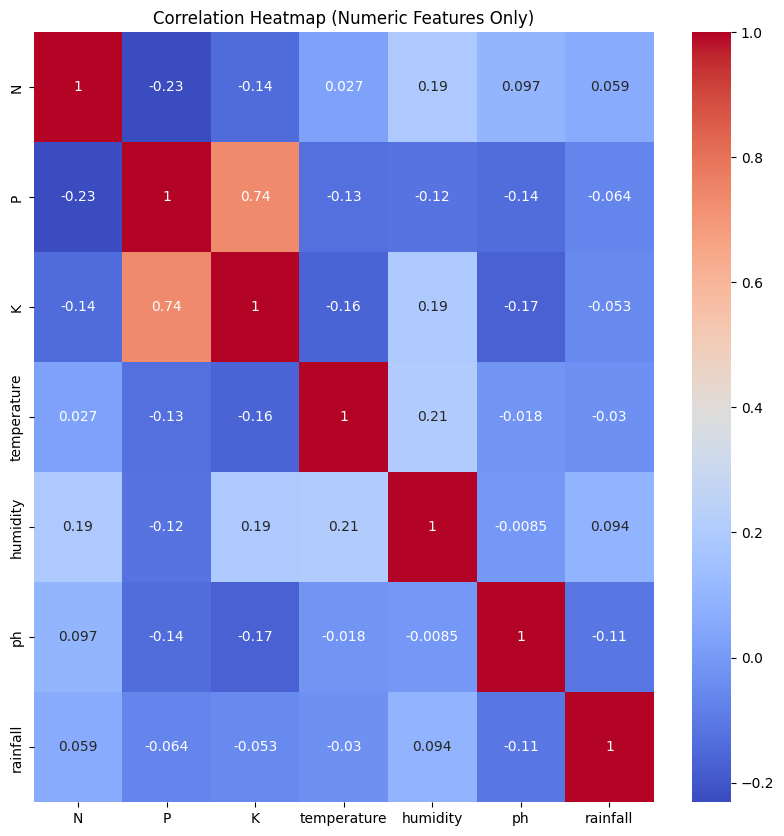

In [3]:


# ========== HEATMAP ==========
plt.figure(figsize=(10, 10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

# ========== FEATURE / LABEL SPLIT ==========
X = df.drop(["label"], axis=1)
Y = df["label"]

# ========== LABEL ENCODING ==========
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)




In [4]:

# ========== TRAIN-TEST SPLIT ==========
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y_encoded, test_size=0.3, random_state=5)

# ========== TRAIN MODEL ==========
XGB = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
XGB.fit(Xtrain, Ytrain)

# ========== PREDICTION ==========
preds = XGB.predict(Xtest)



C:\Users\Balaji\AppData\Local\anaconda3\envs\crop1\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:56:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [5]:
# ========== SINGLE PREDICTION ==========
data = np.array([[90, 42, 43, 20, 82, 6.50, 202.9]])  # example input
prediction = XGB.predict(data)
predicted_crop = le.inverse_transform(prediction)
print("\nPredicted Crop:", predicted_crop[0])

# ========== SAVE MODEL ==========
with open('XGBoostcrop.pkl', 'wb') as f:
    pickle.dump((XGB, le), f)

print("\n✅ Model saved successfully as 'XGBoost.pkl'")


Predicted Crop: rice

✅ Model saved successfully as 'XGBoost.pkl'


In [6]:
# ========== SINGLE PREDICTION ========== 
data = np.array([[90, 42, 43, 20, 82, 6.50, 202.9]]) # example input prediction =
XGB.predict(data)
predicted_crop = le.inverse_transform(prediction) 
print("\nPredicted Crop:", predicted_crop[0])


Predicted Crop: rice


Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        39
      banana       1.00      1.00      1.00        23
   blackgram       1.00      1.00      1.00        31
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        28
      coffee       0.97      1.00      0.98        31
      cotton       0.96      1.00      0.98        24
      grapes       1.00      1.00      1.00        28
        jute       0.96      0.96      0.96        26
 kidneybeans       1.00      1.00      1.00        24
      lentil       1.00      1.00      1.00        25
       maize       1.00      0.97      0.99        35
       mango       1.00      1.00      1.00        29
   mothbeans       1.00      1.00      1.00        34
    mungbean       1.00      1.00      1.00        32
   muskmelon       1.00      1.00      1.00        38
      orange       1.00    

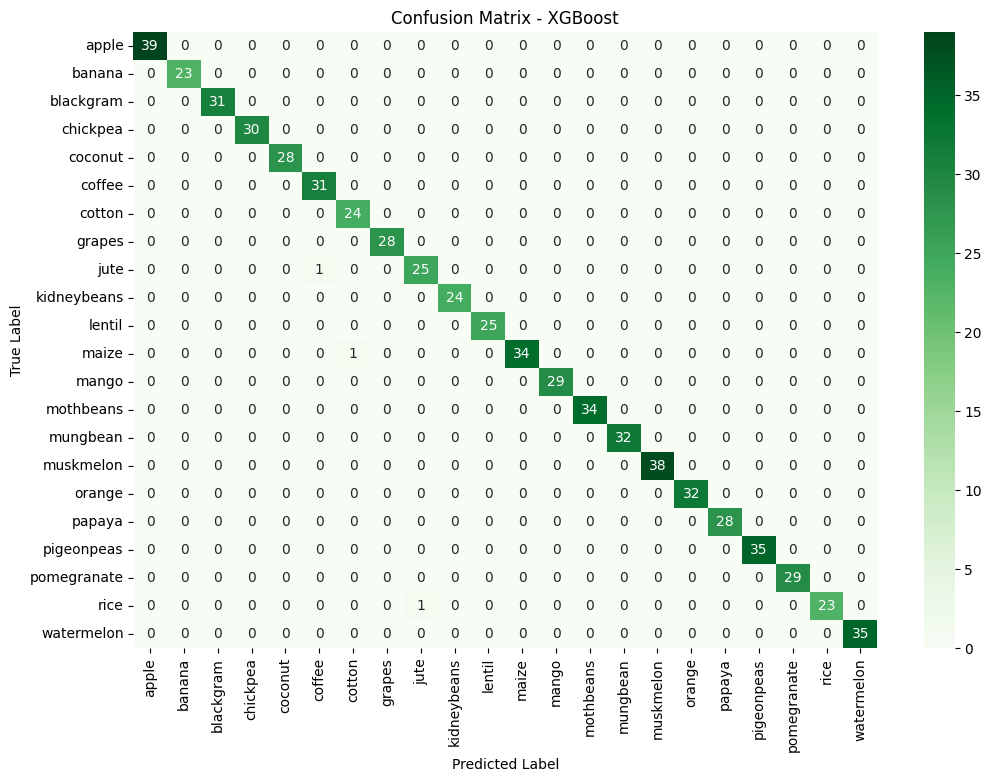

C:\Users\Balaji\AppData\Local\Temp\ipykernel_10088\2052709043.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le.classes_, y=recall_scores, palette="viridis")


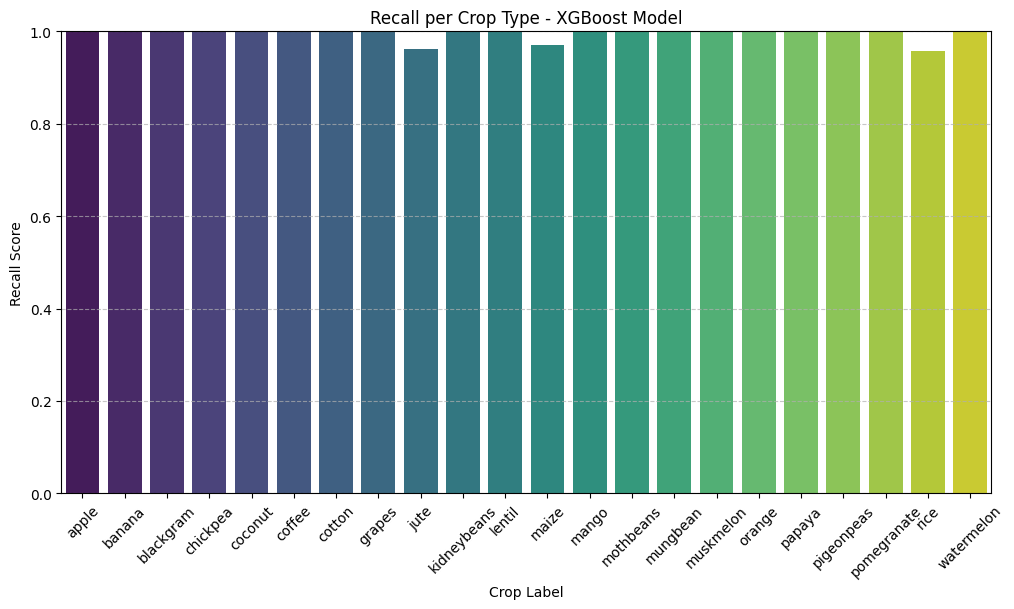

In [7]:
# ========== EVALUATION ==========
print("Accuracy:", accuracy_score(Ytest, preds))
print("\nClassification Report:\n", classification_report(Ytest, preds, target_names=le.classes_))

# ========== CONFUSION MATRIX ==========
plt.figure(figsize=(12, 8))
cm = confusion_matrix(Ytest, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# ========== RECALL DIAGRAM ==========
report = classification_report(Ytest, preds, target_names=le.classes_, output_dict=True)
recall_scores = [report[label]['recall'] for label in le.classes_]

plt.figure(figsize=(12, 6))
sns.barplot(x=le.classes_, y=recall_scores, palette="viridis")
plt.title("Recall per Crop Type - XGBoost Model")
plt.xlabel("Crop Label")
plt.ylabel("Recall Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
